#### 1. Data import and device

In [1]:
from IPython.display import display
import os
import gc
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import imagehash
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from matplotlib import pyplot as plt
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.datasets.folder import default_loader
from tqdm import tqdm

In [2]:

# --- config ---
ROOT = Path().resolve()
DATA_DIR = os.path.join(ROOT, "data", "archive", "train")
TEST_DIR = os.path.join(ROOT, "data", "archive", "test")
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.2
NUM_WORKERS = 4
PIN = torch.cuda.is_available()
device = torch.device("cuda" if PIN else "cpu")
torch.multiprocessing.set_sharing_strategy('file_system')

# More suitable normalization defaults for RGB image classification
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

#Apply various transformations and augmentations to the training images, including color enhancement, flipping, and rotation.
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(10),
    T.ColorJitter(0.1, 0.1, 0.05),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


test_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def get_loaders(
        data_dir: str = DATA_DIR,
        batch_size: int = BATCH_SIZE,
        val_split: float = VAL_SPLIT,
        num_workers: int = NUM_WORKERS,
        pin_memory: bool = PIN,
        cleaned_samples=None,
        cleaned_targets=None,
):
    full = torchvision.datasets.ImageFolder(root=data_dir, transform=train_tf)

    # If a cleaned sample list is provided, apply it to both train and val datasets
    if cleaned_samples is not None:
        full.samples = cleaned_samples
        full.imgs = cleaned_samples
        full.targets = cleaned_targets

    n = len(full)
    n_val = int(n * val_split)
    n_train = n - n_val

    train_set, val_set = random_split(full, [n_train, n_val])

    # Apply val_tf to validation split via a separate dataset object
    val_full = torchvision.datasets.ImageFolder(root=data_dir, transform=val_tf)
    if cleaned_samples is not None:
        val_full.samples = cleaned_samples
        val_full.imgs = cleaned_samples
        val_full.targets = cleaned_targets
    val_set.dataset = val_full

    class_to_idx = full.class_to_idx
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory, drop_last=False
    )
    val_loader = DataLoader(
        val_set, batch_size=batch_size * 2, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory, drop_last=False
    )
    return train_loader, val_loader, idx_to_class

test_dataset = torchvision.datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_tf
)

def get_test_set():
    test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4
    )
    return test_loader

train_loader, val_loader, idx_to_class = get_loaders()

xb, yb = next(iter(train_loader))


#### 2.Data visualization

show image amount, show class amount,and batch size

In [3]:
# ===== Dataset Overview =====

dataset = torchvision.datasets.ImageFolder(root=DATA_DIR)
class_counts = Counter(dataset.targets)

class_table = pd.DataFrame(
    {
        "Class Index": list(range(len(dataset.classes))),
        "Class Name": dataset.classes,
        "Image Count": [class_counts[i] for i in range(len(dataset.classes))],
    }
)

overview = pd.DataFrame(
    {
        "Metric": [
            "Total number of images",
            "Number of classes",
            "Training samples",
            "Validation samples",
            "Train batch size",
            "Validation batch size",
            "Image size",
        ],
        "Value": [
            len(dataset),
            len(dataset.classes),
            len(train_loader.dataset),
            len(val_loader.dataset),
            train_loader.batch_size,
            val_loader.batch_size,
            f"{IMG_SIZE}x{IMG_SIZE}",
        ],
    }
)

display(overview.style.hide(axis="index"))

Metric,Value
Total number of images,11932
Number of classes,16
Training samples,9546
Validation samples,2386
Train batch size,32
Validation batch size,64
Image size,224x224


Display the first 10 images from the dataset.

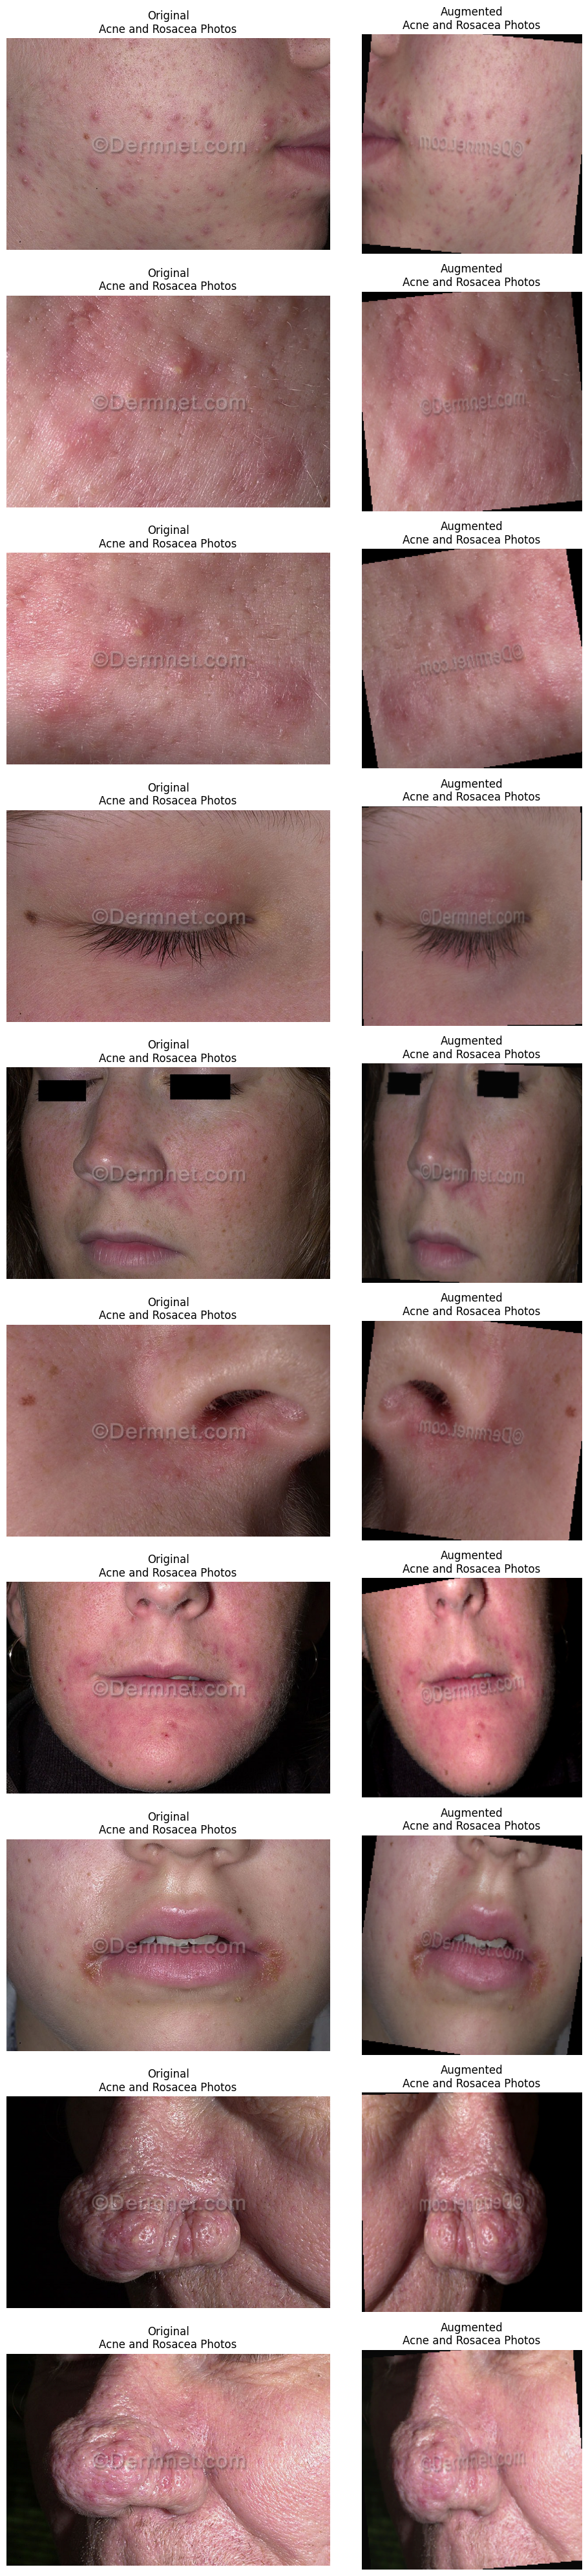

In [4]:
# Compare original images with augmented images from train_tf

def denormalize_image(image_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)
    image_tensor = image_tensor.detach().cpu() * std_tensor + mean_tensor
    return image_tensor.clamp(0, 1).permute(1, 2, 0).numpy()

num_compare = 10
fig, axes = plt.subplots(num_compare, 2, figsize=(10, 4 * num_compare))

for i in range(num_compare):
    original_img, label = dataset[i]
    augmented_img = train_tf(original_img)

    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Original\n{dataset.classes[label]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(denormalize_image(augmented_img))
    axes[i, 1].set_title(f"Augmented\n{dataset.classes[label]}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Count images per class to check class balance.

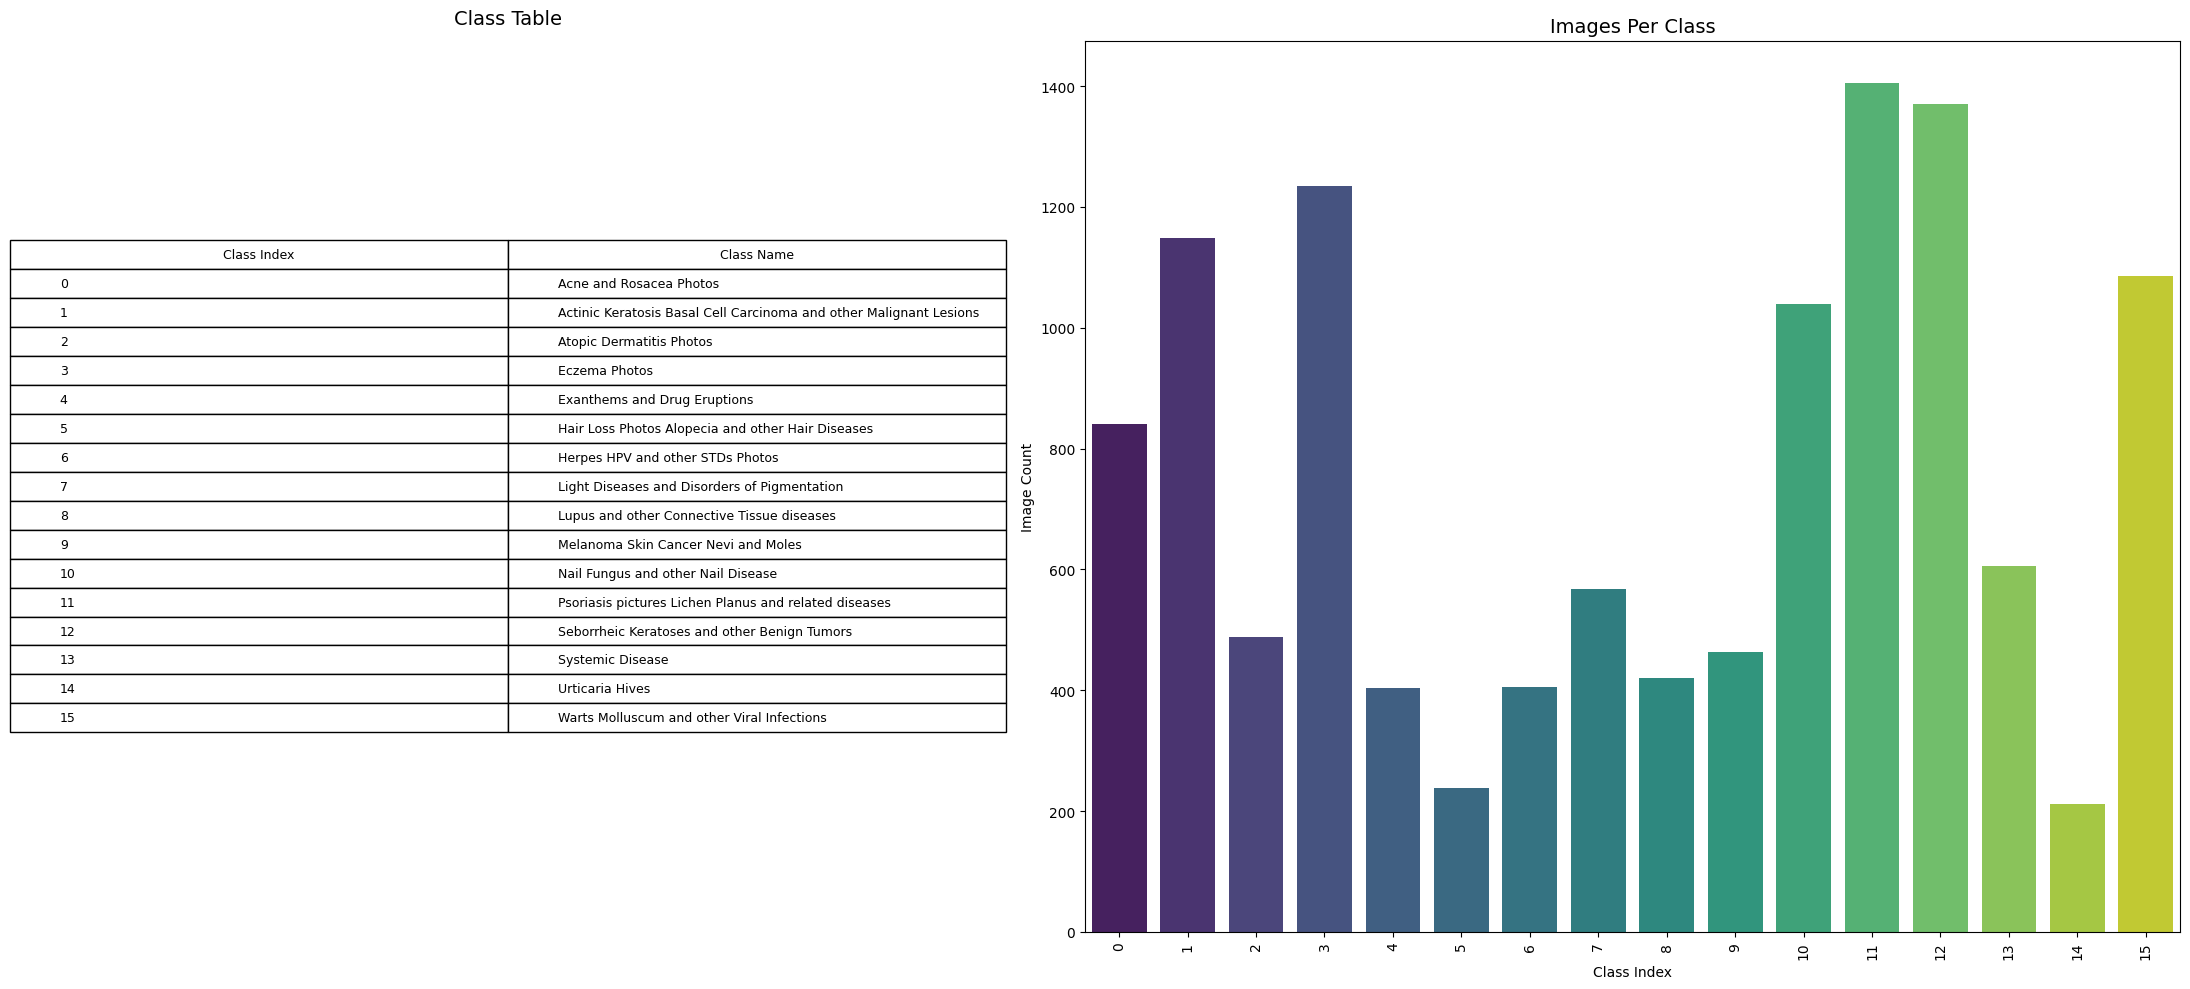

In [5]:
plot_data = class_table.assign(
    **{"Class Index": class_table["Class Index"].astype(str)}
)

fig, (ax_table, ax_bar) = plt.subplots(
    1,
    2,
    figsize=(22, max(10, len(class_table) * 0.4)),
    gridspec_kw={"width_ratios": [2.0, 2.2]},
)

ax_table.axis("off")
table = ax_table.table(
    cellText=class_table[["Class Index", "Class Name"]].values,
    colLabels=["Class Index", "Class Name"],
    loc="center",
    cellLoc="left",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)
ax_table.set_title("Class Table", fontsize=14, pad=12)

sns.barplot(
    data=plot_data,
    x="Class Index",
    y="Image Count",
    hue="Class Index",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax_bar,
  )
ax_bar.set_title("Images Per Class", fontsize=14)
ax_bar.set_xlabel("Class Index")
ax_bar.set_ylabel("Image Count")
ax_bar.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

#### 3. Data cleaning

In [6]:

### 3. Data Cleaning (Robust & Multi-Threaded English Version)
# ─────────────────────────────────────────────────────────────────────
# Step 1: Corrupted & Tiny Image Detection
# ─────────────────────────────────────────────────────────────────────
def verify_image(file_path: Path) -> Path | None:
    """Checks if an image is corrupted or too small to be useful."""
    try:
        with Image.open(file_path) as img:
            img.verify()

        with Image.open(file_path) as img:
            if img.size[0] < 10 or img.size[1] < 10:
                return file_path
        return None
    except (IOError, SyntaxError, UnidentifiedImageError, Exception):
        return file_path

print("=" * 60)
print("Phase 1: Scanning for Corrupted or Invalid Images...")
print("=" * 60)

# Gather all image paths
image_extensions = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}
all_images = [p for p in Path(DATA_DIR).rglob('*') if p.suffix.lower() in image_extensions]
original_count = len(all_images)
print(f"Total images found: {original_count}\n")

# Parallel Verification
with ThreadPoolExecutor(max_workers=NUM_WORKERS * 2) as executor:
    results = list(tqdm(executor.map(verify_image, all_images),
                        total=len(all_images), desc="Verifying Integrity"))

corrupted_files = [res for res in results if res is not None]
# Filter out corrupted files for the next step
valid_images_list = [p for p in all_images if p not in set(corrupted_files)]

# ─────────────────────────────────────────────────────────────────────
# Step 2: Perceptual Hashing — Duplicates & Label Conflicts
# ─────────────────────────────────────────────────────────────────────
def compute_phash(file_path: Path) -> tuple[Path, str | None]:
    """Computes the Perceptual Hash (pHash) of an image."""
    try:
        with Image.open(file_path) as img:
            return file_path, str(imagehash.phash(img))
    except Exception:
        return file_path, None

print("\n" + "=" * 60)
print("Phase 2: Running pHash — Detecting Duplicates & Label Conflicts...")
print("=" * 60)

with ThreadPoolExecutor(max_workers=NUM_WORKERS * 2) as executor:
    hash_results = list(tqdm(executor.map(compute_phash, valid_images_list),
                             total=len(valid_images_list), desc="Computing Hashes"))

# Map hashes to paths and labels: {hash: [(path, label), ...]}
hash_map = defaultdict(list)
for file_path, h in hash_results:
    if h is not None:
        label = file_path.parent.name
        hash_map[h].append((file_path, label))

# Analyze duplicates and conflicts
duplicates_to_remove = set()  # Same image, same label
conflict_files = set()       # Same image, DIFFERENT labels

for h, entries in hash_map.items():
    if len(entries) > 1:
        unique_labels = {label for _, label in entries}

        if len(unique_labels) > 1:
            # MEDICAL SAFETY STRATEGY:
            # If an image has conflicting labels, discard the entire group.
            for p, _ in entries:
                conflict_files.add(p)
        else:
            # Simple Duplicates: Keep the first one, flag the rest for removal.
            for p, _ in entries[1:]:
                duplicates_to_remove.add(p)

# ─────────────────────────────────────────────────────────────────────
# Step 3: Summary Report & Physical Cleanup
# ─────────────────────────────────────────────────────────────────────
files_to_remove = set(corrupted_files) | duplicates_to_remove | conflict_files

# Print conflict examples for debugging
if conflict_files:
    print(f"\nAlert: Label Conflicts Detected! Identical images found in multiple categories:")
    conflict_count = 0
    for h, entries in hash_map.items():
        labels = {label for _, label in entries}
        if len(labels) > 1:
            print(f"   Hash [{h}] → Shared by labels: {labels}")
            conflict_count += 1
            if conflict_count >= 3: break

bad_files_set = {str(p.resolve()) for p in files_to_remove}

valid_samples = []
valid_targets = []

for path, target in dataset.samples:
    if str(Path(path).resolve()) not in bad_files_set:
        valid_samples.append((path, target))
        valid_targets.append(target)

dataset.samples = valid_samples
# imgs: former name of samples;
# Compatibility with legacy code
# Same as the samples (content)
dataset.imgs = valid_samples
dataset.targets = valid_targets

final_count = len(dataset.samples)

print("\n" + "=" * 60)
print("                  DATA CLEANING SUMMARY")
print("=" * 60)
print(f"  {'Initial Image Count:':<35} {original_count:>6}")
print(f"  {'Corrupted / Invalid (Deleted):':<35} {len(corrupted_files):>6}")
print(f"  {'Duplicate Images (Deleted):':<35} {len(duplicates_to_remove):>6}")
print(f"  {'Label Conflicts (Entirely Removed):':<35} {len(conflict_files):>6}")
print("-" * 60)
print(f"  {'Total Images Removed:':<35} {len(files_to_remove):>6}")
print(f"  {'Final Cleaned Dataset Size:':<35} {final_count:>6}")
print(f"  {'Data Retention Rate:':<35} {(final_count/original_count)*100:>5.2f}%")
print("=" * 60)

# ─────────────────────────────────────────────────────────────────────
# Step 4: Rebuild train/val loaders from the cleaned dataset
# ─────────────────────────────────────────────────────────────────────
# The original loaders were built before cleaning and reference a separate
# dataset object. We recreate them here so training uses only clean samples.
train_loader, val_loader, idx_to_class = get_loaders(
    cleaned_samples=dataset.samples,
    cleaned_targets=dataset.targets,
)
print(f"Train samples : {len(train_loader.dataset)}")
print(f"Val samples   : {len(val_loader.dataset)}")


Phase 1: Scanning for Corrupted or Invalid Images...
Total images found: 11932



Verifying Integrity: 100%|██████████| 11932/11932 [00:01<00:00, 8638.76it/s]



Phase 2: Running pHash — Detecting Duplicates & Label Conflicts...


Computing Hashes: 100%|██████████| 11932/11932 [00:05<00:00, 2257.75it/s]



Alert: Label Conflicts Detected! Identical images found in multiple categories:
   Hash [807275b87cbd2a99] → Shared by labels: {'Eczema Photos', 'Acne and Rosacea Photos'}
   Hash [f61c992366cccc33] → Shared by labels: {'Acne and Rosacea Photos', 'Seborrheic Keratoses and other Benign Tumors'}
   Hash [d5b53b29e8e268c1] → Shared by labels: {'Light Diseases and Disorders of Pigmentation', 'Acne and Rosacea Photos'}

                  DATA CLEANING SUMMARY
  Initial Image Count:                 11932
  Corrupted / Invalid (Deleted):           0
  Duplicate Images (Deleted):            286
  Label Conflicts (Entirely Removed):    624
------------------------------------------------------------
  Total Images Removed:                  910
  Final Cleaned Dataset Size:          11022
  Data Retention Rate:                92.37%
Train samples : 8818
Val samples   : 2204


#### 4. Model and comparison model

Our own 20-layer CNN Model

In [7]:
class CNN20Model(nn.Module):
    def __init__(self, num_classes=23):
        super(CNN20Model, self).__init__()

        # Convolutional layers
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

#### 5. Model training

In [8]:

# The entire training dataset was used to train the model for 30 epochs.
EPOCHS = 30
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 8

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()

def get_loader_targets(loader):
    data = loader.dataset
    if hasattr(data, 'targets'):
        return list(data.targets)
    if hasattr(data, 'indices') and hasattr(data.dataset, 'targets'):
        return [data.dataset.targets[i] for i in data.indices]
    raise ValueError('Unable to read targets from the provided loader.')

def get_loader_classes(loader):
    """Get classes from a loader whose dataset may be a Subset."""
    ds = loader.dataset
    if hasattr(ds, 'classes'):
        return ds.classes
    if hasattr(ds, 'dataset') and hasattr(ds.dataset, 'classes'):
        return ds.dataset.classes
    raise ValueError('Unable to read classes from the provided loader.')

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    i=0
    for images, labels in loader:
        print(i)
        i += 1
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY, patience=PATIENCE, model_name="model"):
    """Complete training loop with early stopping and checkpointing."""
    model = model.to(device)
    targets = get_loader_targets(train_loader)

    counts = Counter(targets)
    num_classes = len(get_loader_classes(train_loader))
    total_samples = sum(counts.values())

    class_weights = torch.tensor(
        [total_samples / counts[i] for i in range(num_classes)],
        dtype=torch.float,
        device=device,
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    best_val_acc = 0.0
    best_epoch = 0
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\nStarting training for {model_name}...")
    print("-" * 70)

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)

        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:6.2f}% | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:6.2f}%",
            end="",
            flush=True,
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f" ✓ [Best: {val_acc:.2f}%]")
        else:
            epochs_no_improve += 1
            print(flush=True)

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch + 1}")
            print(f"Best validation accuracy: {best_val_acc:.2f}% (epoch {best_epoch})")
            break

    model.load_state_dict(torch.load(f'best_{model_name}.pth', map_location=device))
    print(f"\nTraining complete. Best model saved as 'best_{model_name}.pth'")
    print("-" * 70)
    return model, history

print("\n" + "=" * 70)
print("TRAINING CUSTOM 20-LAYER CNN MODEL")
print("=" * 70)
NUM_CLASSES = len(idx_to_class)
print(f"Initializing 20-layer CNN for {NUM_CLASSES} classes on device: {device}")
model_20 = CNN20Model(num_classes=NUM_CLASSES).to(device)
model_20, model_20_history = train_model(
    model_20, train_loader, val_loader,
    model_name="cnn_20"
 )



TRAINING CUSTOM 20-LAYER CNN MODEL
Initializing 20-layer CNN for 16 classes on device: cuda

Starting training for cnn_20...
----------------------------------------------------------------------
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
2

#### 6. Model performance comparison

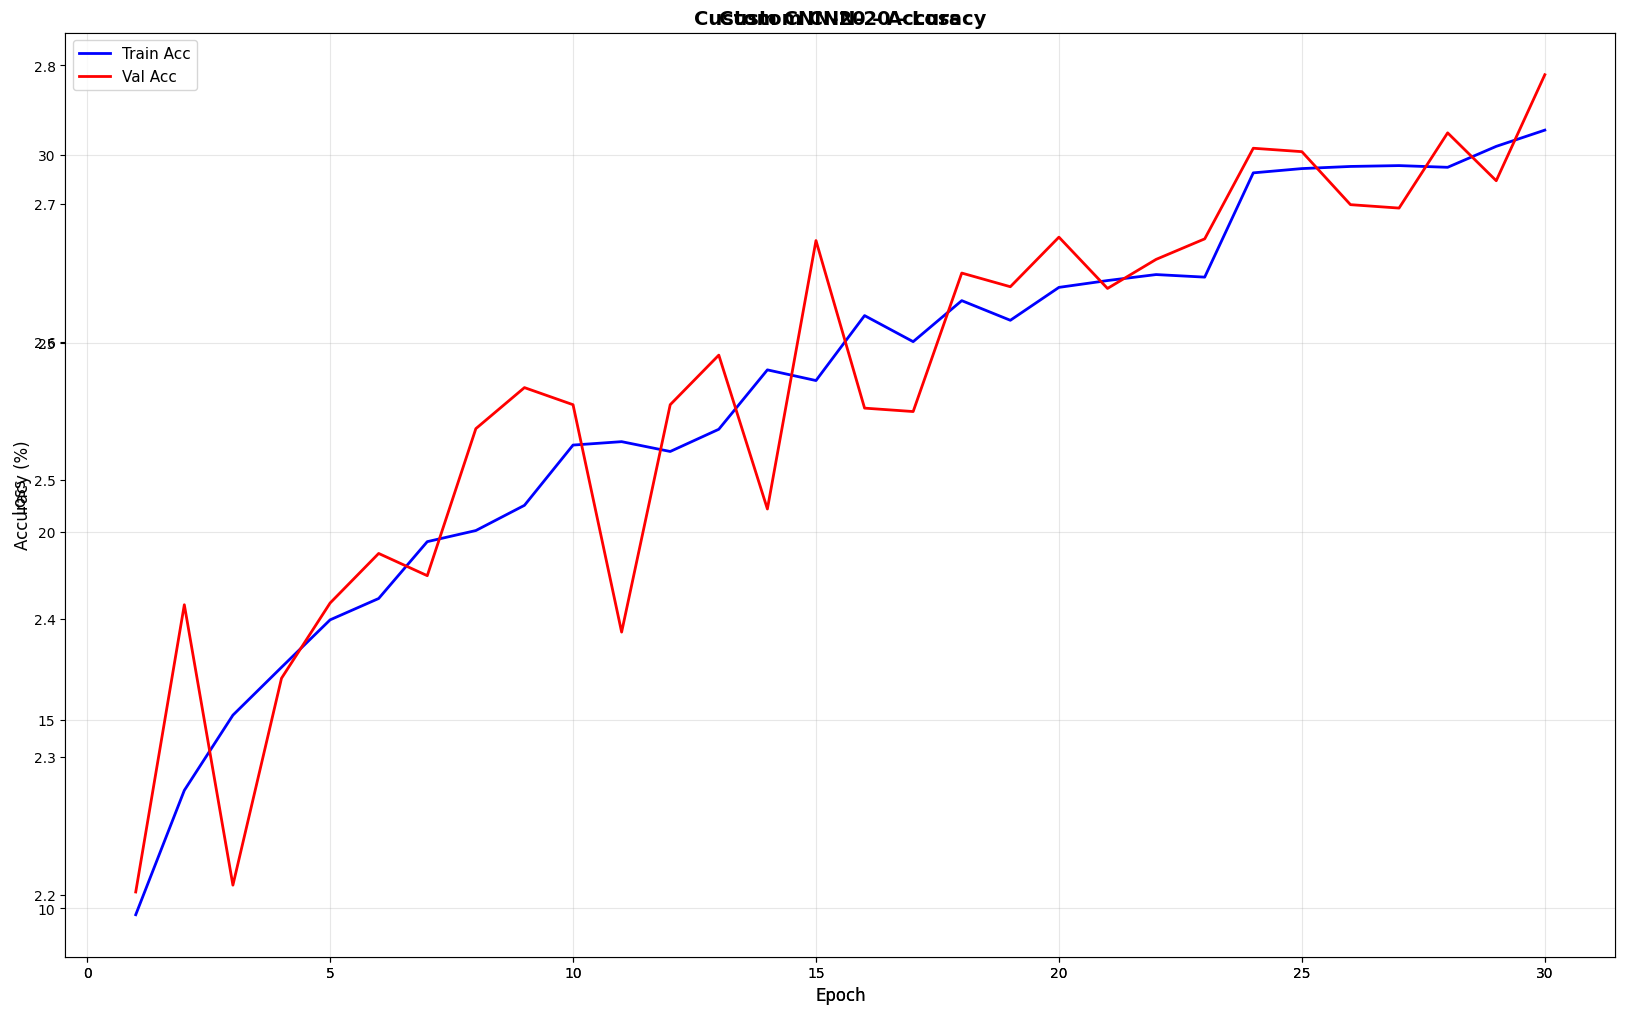

In [9]:
def plot_training_histories( history, model_name):
    """Compare training histories of three models side by side"""
    fig = plt.figure(figsize=(20, 12))

    epochs1 = range(1, len(history['train_loss']) + 1)

    # Model 1 - Loss
    ax1 = fig.add_subplot()
    ax1.plot(epochs1, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    ax1.plot(epochs1, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    ax1.set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)



    # Model 1 - Accuracy
    ax4 = fig.add_subplot()
    ax4.plot(epochs1, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    ax4.plot(epochs1, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    ax4.set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Accuracy (%)', fontsize=12)
    ax4.set_xlabel('Epoch', fontsize=12)
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3)




# Plot comparison of all three models
plot_training_histories(model_20_history, 'Custom CNN-20')


In [10]:
def evaluate_model_pytorch(model, loader, device, k=3):
    """Evaluate PyTorch model and return metrics"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    total_loss = 0.0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total
    accuracy = 100. * correct / total

    # Calculate top-k accuracy
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    top_k_acc = top_k_accuracy_score(all_labels, all_probs, k=k) * 100

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'top_k_accuracy': top_k_acc,
        'predictions': np.array(all_preds),
        'probabilities': all_probs,
        'labels': all_labels
    }


print("Evaluating Custom CNN-20...")
model_20_results = evaluate_model_pytorch(model_20, val_loader, device, k=3)

# Create comparison table
results_df = pd.DataFrame({
    'Model': ['Custom CNN-20'],
    'Validation Loss': [ model_20_results['loss']],
    'Validation Accuracy (%)': [model_20_results['accuracy']],
    'Top-3 Accuracy (%)': [model_20_results['top_k_accuracy']]
})

print("\n" + "=" * 70)
print("=" * 70)
display(results_df.style.format({
    'Validation Loss': '{:.4f}',
    'Validation Accuracy (%)': '{:.2f}',
    'Top-3 Accuracy (%)': '{:.2f}'
}).hide(axis="index"))

Evaluating Custom CNN-20...



Model,Validation Loss,Validation Accuracy (%),Top-3 Accuracy (%)
Custom CNN-20,2.0745,32.12,60.30



CUSTOM CNN-20 CLASSIFICATION REPORT
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos      0.329     0.564     0.415       165
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions      0.367     0.390     0.378       205
                                          Atopic Dermatitis Photos      0.288     0.204     0.239       103
                                                     Eczema Photos      0.348     0.306     0.326       232
                                      Exanthems and Drug Eruptions      0.194     0.273     0.226        66
                 Hair Loss Photos Alopecia and other Hair Diseases      0.229     0.774     0.353        31
                                  Herpes HPV and other STDs Photos      0.129     0.450     0.200        60
                      Light Diseases and Disorders of Pigmentation      0.243     0.149     0.185 

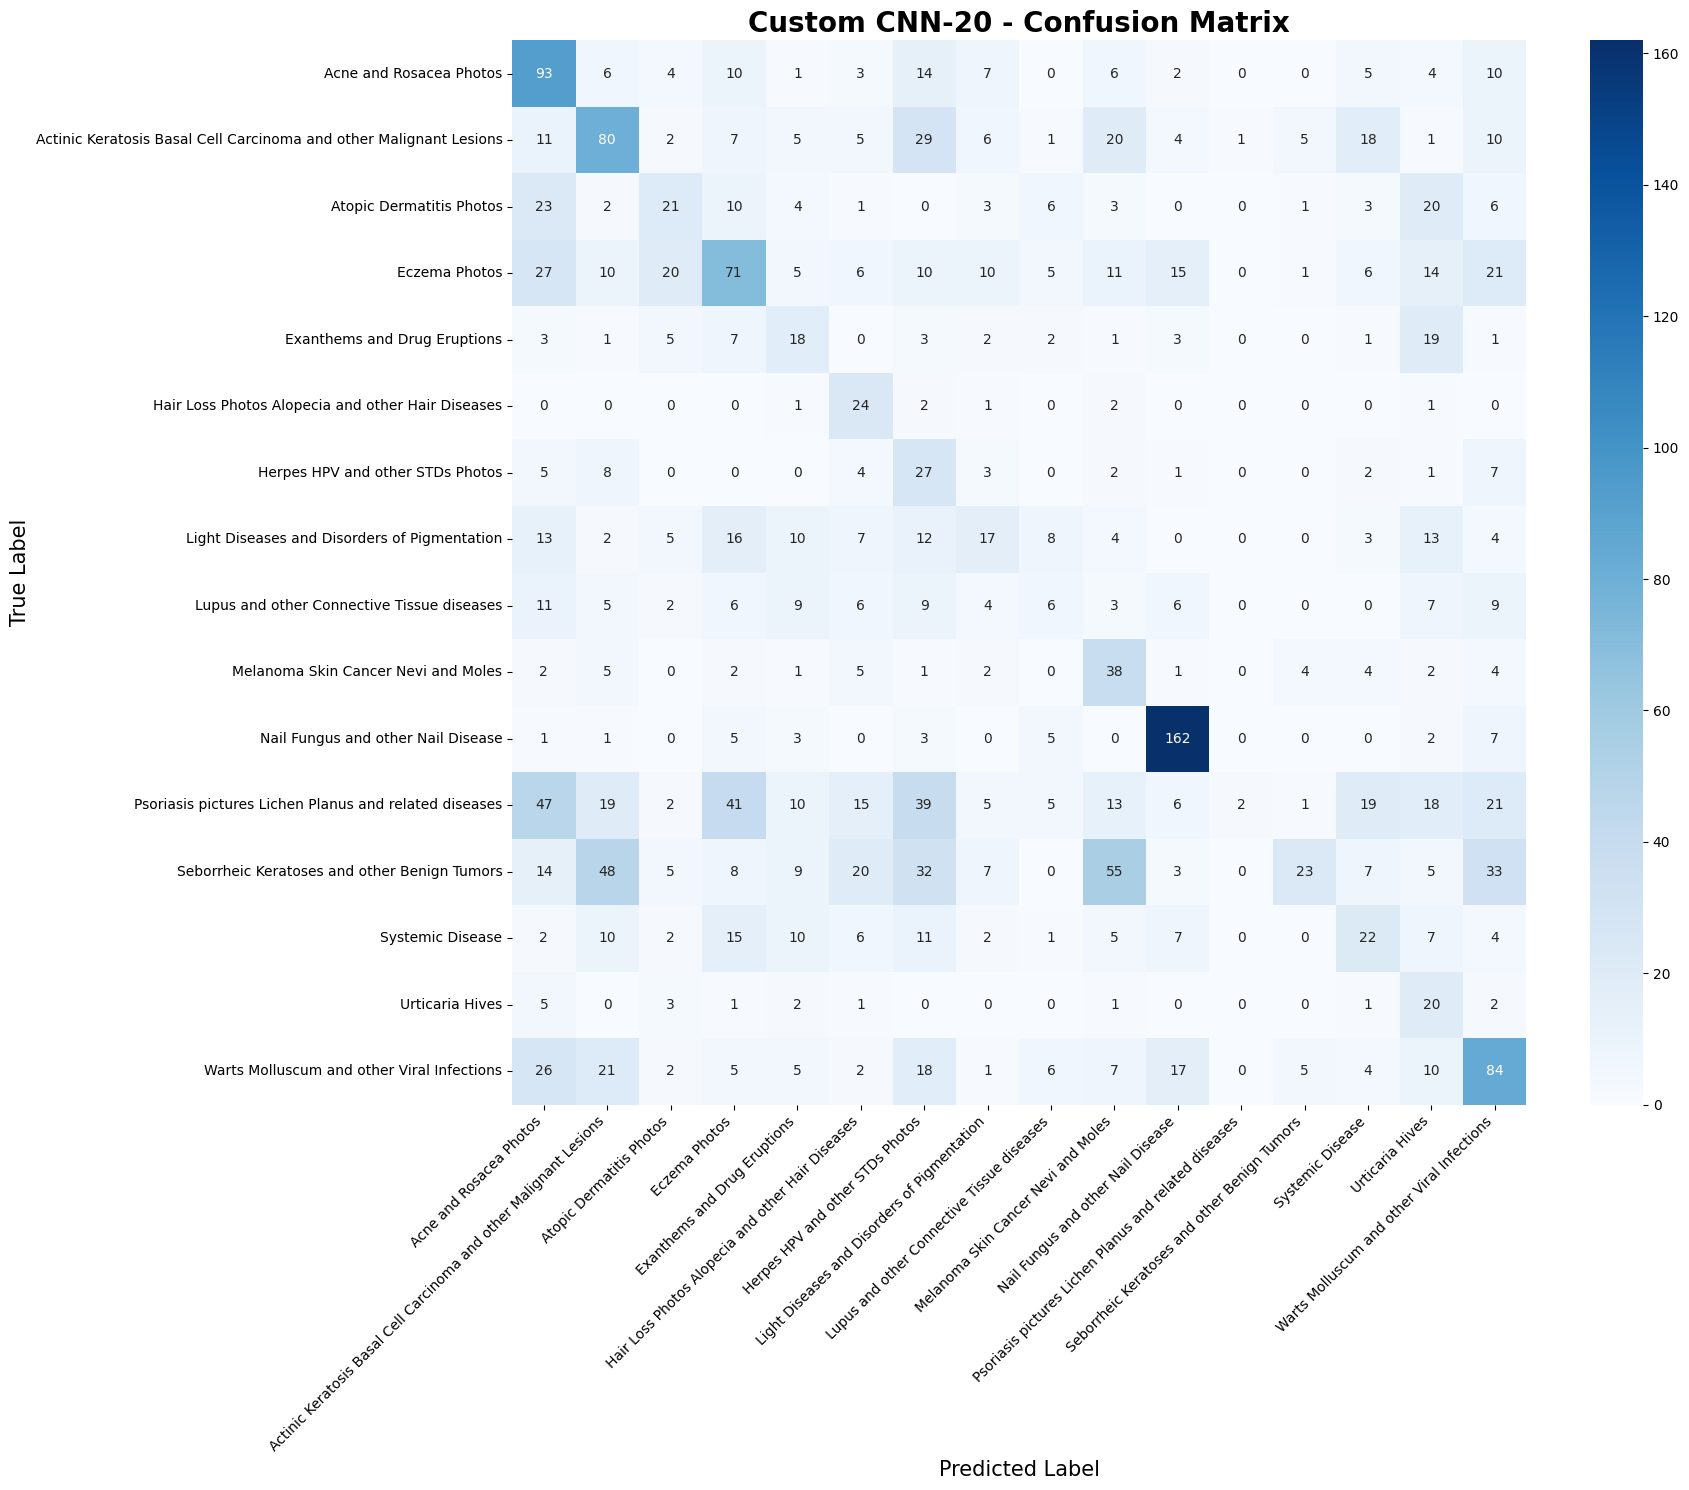

In [11]:
class_names = list(idx_to_class.values())
print("\n" + "=" * 70)
print("CUSTOM CNN-20 CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(model_20_results['labels'], model_20_results['predictions'],
                          target_names=class_names, digits=3))

def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    """Plot confusion matrix heatmap"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=20, fontweight='bold')
    plt.ylabel('True Label', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(model_20_results['labels'], model_20_results['predictions'],
                     'Custom CNN-20', class_names)


In [12]:
test_loader = get_test_set()
criterion = nn.CrossEntropyLoss()

test_loader = get_test_set()

test_loss, test_acc = validate(model_20, test_loader, criterion, device)

model_20_test_results = evaluate_model_pytorch(model_20, test_loader, device, k=3)

results_df = pd.DataFrame({
    'Model': ['Custom CNN-20'],
    'Test Loss': [model_20_test_results['loss']],
    'Test Accuracy (%)': [model_20_test_results['accuracy']],
    'Top-3 Test Accuracy (%)': [model_20_test_results['top_k_accuracy']]
})

print("\n" + "=" * 70)
print("FINAL TEST RESULTS")
print("=" * 70)
display(results_df.style.format({
    'Test Loss': '{:.4f}',
    'Test Accuracy (%)': '{:.2f}',
    'Top-3 Test Accuracy (%)': '{:.2f}'
}).hide(axis="index"))



plot_confusion_matrix(model_20_test_results['labels'], model_20_test_results['predictions'],'Custom CNN-20', class_names)

FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "C:\Users\111\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\_utils\worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "C:\Users\111\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torch\utils\data\_utils\fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "C:\Users\111\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\datasets\folder.py", line 245, in __getitem__
    sample = self.loader(path)
  File "C:\Users\111\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.